A histogram is a way to visualise a distribution of numerical data.

It shows how many values fall into each range (bin).

Can be thought of as grouping numbers into buckets and then counting them.

E.g.
You have 50 exam grades. A histogram can show how many students scored <br>
0-10, 10-20, 20-30, etc.

In [4]:
import numpy as np

In [5]:
import pandas as pd

Import the 'Series' class from the pandas module.

In [6]:
from pandas import Series

In [7]:
import matplotlib.pyplot as plt

In [8]:
# A seed is a number used to initialise the random number generator.

# Using a seed makes the sequence of "random" numbers reproducible.
# This means you will get the same results every time you run the code.
# The numbers still appear random, but they are deterministic.

# 42 is commonly used as a default seed by convention.
np.random.seed(42)

print(np.random.randint(0, 11, size=5))

[ 6  3 10  7  4]


In [9]:
np.random.seed(123)

print(np.random.randint(0, 11, size=5))

[2 2 6 1 3]


In [10]:
# np.random.randint(low, high) generates integers from low up
# to but not including high.

# So using 0 to 101 includes both 0 and 100.

# size=50 generates 50 values.

# The return value is a NumPy array (ndarray).
grades = np.random.randint(0, 101, size=50)

In [11]:
grades

array([ 57,  86,  97,  96,  47,  73,  32,  46,  96,  25,  83,  78,  36,
        96,  80,  68,  49,  55,  67,   2,  84,  39,  66,  84,  47,  61,
        48,   7,  99,  92,  52,  97,  85,  94,  27,  34,  97,  76,  40,
         3,  69,  64,  75,  34,  58,  10,  22,  77,  18, 100])

In [12]:
type(grades)

numpy.ndarray

Convert the ndarray to a Pandas Series.

A Series can be thought of as:
- a list
- with indexes (labels)
- and built-in math and statistics tools

In [13]:
grades_series = Series(grades)

The first column contains the index labels.

The second column contains the actual data values, in this case, the grades.

When you create a Series, pandas automatically assigns an index starting at <br>
0 unless you specify one yourself.

In [14]:
grades_series

0      57
1      86
2      97
3      96
4      47
5      73
6      32
7      46
8      96
9      25
10     83
11     78
12     36
13     96
14     80
15     68
16     49
17     55
18     67
19      2
20     84
21     39
22     66
23     84
24     47
25     61
26     48
27      7
28     99
29     92
30     52
31     97
32     85
33     94
34     27
35     34
36     97
37     76
38     40
39      3
40     69
41     64
42     75
43     34
44     58
45     10
46     22
47     77
48     18
49    100
dtype: int64

Sort the grades in ascending order (smallest to largest).

In [15]:
grades_series.sort_values()

19      2
39      3
27      7
45     10
48     18
46     22
9      25
34     27
6      32
35     34
43     34
12     36
21     39
38     40
7      46
4      47
24     47
26     48
16     49
30     52
17     55
0      57
44     58
25     61
41     64
22     66
18     67
15     68
40     69
5      73
42     75
37     76
47     77
11     78
14     80
10     83
23     84
20     84
32     85
1      86
29     92
33     94
8      96
13     96
3      96
36     97
31     97
2      97
28     99
49    100
dtype: int64

Sort the grades in descending order (largest to smallest) <br>
by including the keyword argument 'ascending=False'.

In [16]:
grades_series.sort_values(ascending=False)

49    100
28     99
2      97
31     97
36     97
8      96
13     96
3      96
33     94
29     92
1      86
32     85
23     84
20     84
10     83
14     80
11     78
47     77
37     76
42     75
5      73
40     69
15     68
18     67
22     66
41     64
25     61
44     58
0      57
17     55
30     52
16     49
26     48
24     47
4      47
7      46
38     40
21     39
12     36
35     34
43     34
6      32
34     27
9      25
46     22
48     18
45     10
27      7
39      3
19      2
dtype: int64

Plot a histogram of the grades.

<AxesSubplot: >

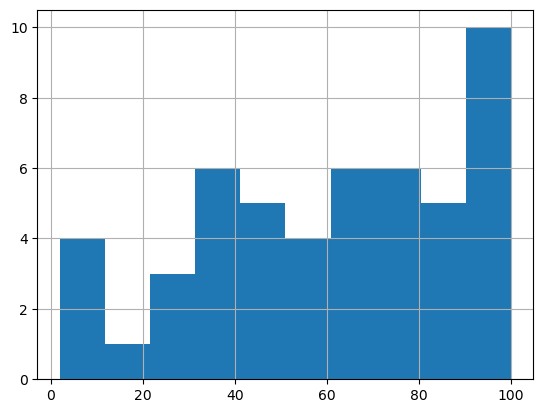

In [17]:
grades_series.hist()

Altering the horizontal size or width of the bins the represent <br>
the frequency of values in a range.

<AxesSubplot: >

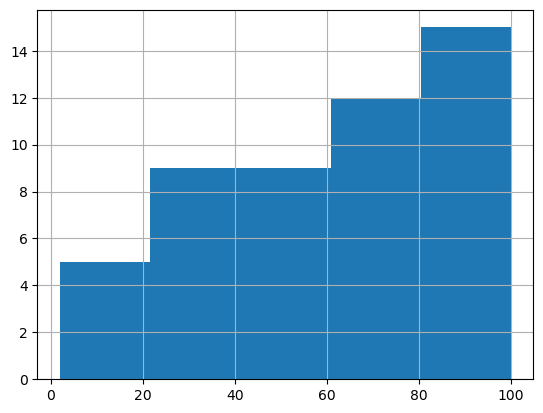

In [18]:
grades_series.hist(bins=5)

Step 1: Define the bins for grouping grades

range(0, 101, 10) creates bins: [0-9], [10-19], ..., [90-100]

In [19]:
bins = range(0, 101, 10)

Step 2: Assign each grade to a bin

pd.cut() categorizes the grades in grades_series into the bins we defined.

right=False means the bins are left-inclusive and right-exclusive, <br>
e.g., 0-10 includes 0 but not 10.

In [20]:
grades_binned = pd.cut(grades_series, bins=bins, right=False)

Step 3: Count how many grades fall into each bin

value_counts() counts occurrences in each bin.

sort_index() ensures the bins are in numerical order.

In [21]:
bin_counts = grades_binned.value_counts().sort_index()

In [22]:
bin_counts

[0, 10)      3
[10, 20)     2
[20, 30)     3
[30, 40)     5
[40, 50)     6
[50, 60)     4
[60, 70)     6
[70, 80)     5
[80, 90)     6
[90, 100)    9
Name: count, dtype: int64

Step 4: Plot the bin counts as a pie chart

autopct="%1.2f%%" shows the percentage for each slice with 2 decimal places.

The first % belongs to the %.2f placeholder. It is needed because it marks <br>
the start of a format specifier.

% starts a format specifier.

.2 rounds the number to 2 decimal places.

f formats as a floating-point number.

There are two percentage signs (%%) at the end because a single % in a string <br>
must be escaped by doubling it.

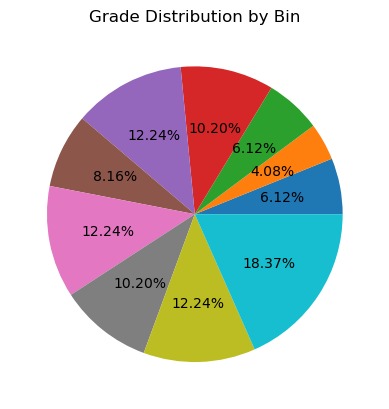

In [25]:
plt.pie(bin_counts, autopct="%.2f%%")
plt.title("Grade Distribution by Bin")
plt.show()